In [1]:
#import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score


In [2]:
# Load the synthetic dataset
df = pd.read_csv('synthetic_diabetes_data.csv')

# Quick check
df.head()


,Historic Glucose (mmol/L),Scan Glucose (mmol/L),Rapid-Acting Insulin (units),Long-Acting Insulin (units),Carbohydrates (grams),Thirst,Nausea,Weakness,Vomiting,Fatigue,Shakiness,Condition
0,9.4,7.2,3,17,75,0,0,1,0,1,0,2
1,19.2,17.5,5,13,113,1,1,1,1,1,0,3
2,15.4,16.0,7,14,94,1,1,1,1,1,0,3
3,13.2,11.4,15,13,53,0,0,0,0,0,0,2
4,5.7,7.4,7,14,144,1,1,0,0,0,0,2


In [3]:

# Map numeric labels to condition names
condition_map = {0: "Hypoglycemia", 1: "Normal", 2: "Hyperglycemia", 3: "DKA"}
y = df['Condition']

# Unique numeric labels
unique_labels = y.unique()
print("Unique numeric labels:", unique_labels)

# Unique condition names
unique_conditions = [condition_map[label] for label in unique_labels]
print("Unique conditions:", unique_conditions)


Unique numeric labels: [2 3 1 0]
Unique conditions: ['Hyperglycemia', 'DKA', 'Normal', 'Hypoglycemia']


In [4]:
# Features (all columns except 'Condition')
X = df.drop('Condition', axis=1)

# Labels (Condition column)
y = df['Condition']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [5]:
# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
# Read the CSV using tab separator
real_df = pd.read_csv('real_data.csv', sep='\t')

# Check column names
print(real_df.columns)

# Check column names

print("Columns in file:\n", real_df.columns.tolist())


Index(['ID', 'Time', 'Record Type', 'Historic Glucose (mmol/L)',
       'Scan Glucose (mmol/L)', 'Non-numeric Rapid-Acting Insulin',
       'Rapid-Acting Insulin (units)', 'Non-numeric Food',
       'Carbohydrates (grams)', 'Non-numeric Long-Acting Insulin',
       'Long-Acting Insulin (units)', 'Notes', 'Strip Glucose (mmol/L)',
       'Ketone (mmol/L)', 'Meal Insulin (units)', 'Correction Insulin (units)',
       'User Change Insulin (units)', 'Previous Time', 'Updated Time'],
      dtype='object')
Columns in file:
 ['ID', 'Time', 'Record Type', 'Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)', 'Non-numeric Rapid-Acting Insulin', 'Rapid-Acting Insulin (units)', 'Non-numeric Food', 'Carbohydrates (grams)', 'Non-numeric Long-Acting Insulin', 'Long-Acting Insulin (units)', 'Notes', 'Strip Glucose (mmol/L)', 'Ketone (mmol/L)', 'Meal Insulin (units)', 'Correction Insulin (units)', 'User Change Insulin (units)', 'Previous Time', 'Updated Time']


In [7]:
# Select only columns relevant to the model
needed_cols = [
    'Historic Glucose (mmol/L)',
    'Scan Glucose (mmol/L)',
    'Rapid-Acting Insulin (units)',
    'Long-Acting Insulin (units)',
    'Carbohydrates (grams)'
]

# Keep only required columns
real_df = real_df[needed_cols]

# Check for missing values
print("Missing values before filling:\n", real_df.isnull().sum())


Missing values before filling:
 Historic Glucose (mmol/L)        1676
Scan Glucose (mmol/L)           11632
Rapid-Acting Insulin (units)    12788
Long-Acting Insulin (units)     12920
Carbohydrates (grams)           12781
dtype: int64


In [8]:
#  — Clean and replace zeros with median value
import numpy as np

# Replace zeros with NaN for easy processing
real_df['Historic Glucose (mmol/L)'] = real_df['Historic Glucose (mmol/L)'].replace(0, np.nan)

# Compute median of valid values
median_glucose = real_df['Historic Glucose (mmol/L)'].median()

# Fill missing values with median
real_df['Historic Glucose (mmol/L)'] = real_df['Historic Glucose (mmol/L)'].fillna(median_glucose)

print(" Historic Glucose cleaned — zeros replaced with median value:", median_glucose)


 Historic Glucose cleaned — zeros replaced with median value: 7.7


In [9]:
#  — Fix Scan Glucose zeros using Historic Glucose or median
median_scan = real_df['Scan Glucose (mmol/L)'].median()

real_df['Scan Glucose (mmol/L)'] = real_df.apply(
    lambda row: row['Historic Glucose (mmol/L)']
    if row['Scan Glucose (mmol/L)'] == 0 else row['Scan Glucose (mmol/L)'],
    axis=1
)

# Fill any remaining zeros with the median value
real_df['Scan Glucose (mmol/L)'] = real_df['Scan Glucose (mmol/L)'].replace(0, median_scan)

# Confirm fix
print(" Scan Glucose cleaned — summary:")
print(real_df[['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)']].describe())


 Scan Glucose cleaned — summary:
       Historic Glucose (mmol/L)  Scan Glucose (mmol/L)
count               12949.000000            1317.000000
mean                    8.085667               8.795444
std                     2.866533               3.019155
min                     2.200000               2.900000
25%                     6.200000               6.400000
50%                     7.700000               8.400000
75%                     9.600000              10.900000
max                    24.200000              19.100000


In [10]:
# Create symptom columns initialized to 0
symptom_cols = ['Thirst', 'Nausea', 'Weakness', 'Vomiting', 'Fatigue', 'Shakiness']
for col in symptom_cols:
    real_df[col] = 0

# Apply logic based on glucose levels (FIXED TO MATCH TRAINING DATA)
for i, row in real_df.iterrows():
    glucose = row['Scan Glucose (mmol/L)']
    
    # Hypoglycemia (<3.9)
    if glucose < 3.9:
        real_df.at[i, 'Shakiness'] = 1
        real_df.at[i, 'Weakness'] = 1
        real_df.at[i, 'Fatigue'] = 1
    
    # NORMAL RANGE (3.9-7.0)
    elif 3.9 <= glucose < 7.0:
        # Borderline low (3.9-5.0) might have mild shakiness
        if glucose < 5.0:
            real_df.at[i, 'Shakiness'] = 1
    
    # Hyperglycemia (7.0-13.9) - FIXED: Changed from 10 to 7
    elif 7.0 <= glucose < 14.0:  # FIXED: Match training threshold
        real_df.at[i, 'Thirst'] = 1
        real_df.at[i, 'Fatigue'] = 1
        # Add Nausea for higher hyperglycemia
        if glucose >= 10:
            real_df.at[i, 'Nausea'] = 1
    
    # DKA (≥14.0) - FIXED: Changed from >13.9 to >=14
    elif glucose >= 14.0:  # FIXED: Match training threshold
        real_df.at[i, 'Thirst'] = 1
        real_df.at[i, 'Nausea'] = 1
        real_df.at[i, 'Vomiting'] = 1
        real_df.at[i, 'Fatigue'] = 1
        real_df.at[i, 'Weakness'] = 1

print(" Symptoms assigned successfully!")
print("\nSample data:")
print(real_df[['Scan Glucose (mmol/L)', 'Shakiness', 'Thirst', 'Fatigue']].head())

 Symptoms assigned successfully!

Sample data:
   Scan Glucose (mmol/L)  Shakiness  Thirst  Fatigue
0                    8.8          0       1        1
1                   10.4          0       1        1
2                    NaN          0       0        0
3                   14.2          0       1        1
4                   14.5          0       1        1


In [11]:
# Show the updated dataframe with all important columns
print("Final cleaned and symptom-augmented dataset:\n")
real_df[
    [
        'Historic Glucose (mmol/L)',
        'Scan Glucose (mmol/L)',
        'Rapid-Acting Insulin (units)',
        'Long-Acting Insulin (units)',
        'Carbohydrates (grams)',
        'Thirst',
        'Nausea',
        'Weakness',
        'Vomiting',
        'Fatigue',
        'Shakiness'
    ]
].head(20) 


Final cleaned and symptom-augmented dataset:



,Historic Glucose (mmol/L),Scan Glucose (mmol/L),Rapid-Acting Insulin (units),Long-Acting Insulin (units),Carbohydrates (grams),Thirst,Nausea,Weakness,Vomiting,Fatigue,Shakiness
0,7.7,8.8,NaN,NaN,NaN,1,0,0,0,1,0
1,7.7,10.4,NaN,NaN,NaN,1,1,0,0,1,0
2,7.7,NaN,2.0,NaN,NaN,0,0,0,0,0,0
3,7.7,14.2,NaN,NaN,NaN,1,1,1,1,1,0
4,7.7,14.5,NaN,NaN,NaN,1,1,1,1,1,0
5,7.7,6.2,NaN,NaN,NaN,0,0,0,0,0,0
6,7.7,6.2,NaN,NaN,NaN,0,0,0,0,0,0
7,7.7,NaN,NaN,12.0,NaN,0,0,0,0,0,0
8,7.7,6.8,NaN,NaN,NaN,0,0,0,0,0,0
9,7.7,6.2,NaN,NaN,NaN,0,0,0,0,0,0


In [12]:
#  — Arrange columns in the same order as training
feature_cols = [
    'Historic Glucose (mmol/L)',
    'Scan Glucose (mmol/L)',
    'Rapid-Acting Insulin (units)',
    'Long-Acting Insulin (units)',
    'Carbohydrates (grams)'
] + symptom_cols

real_df = real_df[feature_cols]

print(" Final dataset ready for prediction:")
display(real_df.head())


 Final dataset ready for prediction:


,Historic Glucose (mmol/L),Scan Glucose (mmol/L),Rapid-Acting Insulin (units),Long-Acting Insulin (units),Carbohydrates (grams),Thirst,Nausea,Weakness,Vomiting,Fatigue,Shakiness
0,7.7,8.8,NaN,NaN,NaN,1,0,0,0,1,0
1,7.7,10.4,NaN,NaN,NaN,1,1,0,0,1,0
2,7.7,NaN,2.0,NaN,NaN,0,0,0,0,0,0
3,7.7,14.2,NaN,NaN,NaN,1,1,1,1,1,0
4,7.7,14.5,NaN,NaN,NaN,1,1,1,1,1,0


In [13]:
# Fill insulin and carb NaNs with 0 (means no dose or no meal)
real_df['Rapid-Acting Insulin (units)'] = real_df['Rapid-Acting Insulin (units)'].fillna(0)
real_df['Long-Acting Insulin (units)'] = real_df['Long-Acting Insulin (units)'].fillna(0)
real_df['Carbohydrates (grams)'] = real_df['Carbohydrates (grams)'].fillna(0)

# Use ffill() instead of fillna(method='ffill') - NEW SYNTAX
real_df['Scan Glucose (mmol/L)'] = real_df['Scan Glucose (mmol/L)'].ffill()
real_df['Historic Glucose (mmol/L)'] = real_df['Historic Glucose (mmol/L)'].ffill()

# Fill any remaining NaNs with median
real_df['Scan Glucose (mmol/L)'] = real_df['Scan Glucose (mmol/L)'].fillna(
    real_df['Scan Glucose (mmol/L)'].median()
)
real_df['Historic Glucose (mmol/L)'] = real_df['Historic Glucose (mmol/L)'].fillna(
    real_df['Historic Glucose (mmol/L)'].median()
)

print("Missing values after cleaning:\n", real_df.isnull().sum())
real_df.head()

Missing values after cleaning:
 Historic Glucose (mmol/L)       0
Scan Glucose (mmol/L)           0
Rapid-Acting Insulin (units)    0
Long-Acting Insulin (units)     0
Carbohydrates (grams)           0
Thirst                          0
Nausea                          0
Weakness                        0
Vomiting                        0
Fatigue                         0
Shakiness                       0
dtype: int64


,Historic Glucose (mmol/L),Scan Glucose (mmol/L),Rapid-Acting Insulin (units),Long-Acting Insulin (units),Carbohydrates (grams),Thirst,Nausea,Weakness,Vomiting,Fatigue,Shakiness
0,7.7,8.8,0.0,0.0,0.0,1,0,0,0,1,0
1,7.7,10.4,0.0,0.0,0.0,1,1,0,0,1,0
2,7.7,10.4,2.0,0.0,0.0,0,0,0,0,0,0
3,7.7,14.2,0.0,0.0,0.0,1,1,1,1,1,0
4,7.7,14.5,0.0,0.0,0.0,1,1,1,1,1,0


In [14]:
# First, assign conditions using CONSISTENT logic
#true labels to compare against the model’s predictions
def assign_condition(glucose):
    """
    Consistent with training data thresholds:
    - < 3.9: Hypoglycemia (0)
    - 3.9 - 7.0: Normal (1)  
    - 7.0 - 14.0: Hyperglycemia (2)
    - >= 14.0: DKA (3)
    """
    if glucose < 3.9:
        return 0
    elif glucose < 7.0:
        return 1
    elif glucose < 14.0:
        return 2
    else:
        return 3

# Assign conditions BEFORE balancing
real_df['Condition'] = real_df['Scan Glucose (mmol/L)'].apply(assign_condition)

# Now prepare features
feature_cols = X.columns
X_real = real_df[feature_cols]
X_real = X_real.fillna(X_real.mean())

print(" Real features ready for prediction.")
print("Condition distribution:\n", real_df['Condition'].value_counts().sort_index())
X_real.head()

 Real features ready for prediction.
Condition distribution:
 Condition
0       29
1      523
2    12303
3       94
Name: count, dtype: int64


,Historic Glucose (mmol/L),Scan Glucose (mmol/L),Rapid-Acting Insulin (units),Long-Acting Insulin (units),Carbohydrates (grams),Thirst,Nausea,Weakness,Vomiting,Fatigue,Shakiness
0,7.7,8.8,0.0,0.0,0.0,1,0,0,0,1,0
1,7.7,10.4,0.0,0.0,0.0,1,1,0,0,1,0
2,7.7,10.4,2.0,0.0,0.0,0,0,0,0,0,0
3,7.7,14.2,0.0,0.0,0.0,1,1,1,1,1,0
4,7.7,14.5,0.0,0.0,0.0,1,1,1,1,1,0


In [15]:
from collections import Counter

# Check current distribution
print("Original class distribution:")
print(real_df['Condition'].value_counts().sort_index())

# find minimum class size
class_counts = Counter(real_df['Condition'])
min_samples = min(class_counts.values())

print(f"\nBalancing to minimum class size: {min_samples} samples per class")

# Balance the dataset by sampling
balanced_dfs = []
for condition_class in range(4):
    class_df = real_df[real_df['Condition'] == condition_class]
    
    if len(class_df) >= min_samples:
        sampled = class_df.sample(min_samples, random_state=42)
    else:
        print(f" Warning: Class {condition_class} has only {len(class_df)} samples")
        sampled = class_df  # Use all available
    
    balanced_dfs.append(sampled)

balanced_real_df = pd.concat(balanced_dfs, ignore_index=True)
print(f"\nBalanced dataset size: {len(balanced_real_df)}")
print("\nBalanced class distribution:")
print(balanced_real_df['Condition'].value_counts().sort_index())

Original class distribution:
Condition
0       29
1      523
2    12303
3       94
Name: count, dtype: int64

Balancing to minimum class size: 29 samples per class

Balanced dataset size: 116

Balanced class distribution:
Condition
0    29
1    29
2    29
3    29
Name: count, dtype: int64


In [16]:
# Ensure columns match training data exactly
X_real = balanced_real_df[X_train.columns]  # Use X_train columns order
y_true = balanced_real_df['Condition']

# Verify
print("Training features:", X_train.columns.tolist())
print("Real data features:", X_real.columns.tolist())
print("Features match:", list(X_train.columns) == list(X_real.columns))
print("\nMissing values:", X_real.isnull().sum().sum())

Training features: ['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)', 'Rapid-Acting Insulin (units)', 'Long-Acting Insulin (units)', 'Carbohydrates (grams)', 'Thirst', 'Nausea', 'Weakness', 'Vomiting', 'Fatigue', 'Shakiness']
Real data features: ['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)', 'Rapid-Acting Insulin (units)', 'Long-Acting Insulin (units)', 'Carbohydrates (grams)', 'Thirst', 'Nausea', 'Weakness', 'Vomiting', 'Fatigue', 'Shakiness']
Features match: True

Missing values: 0


 Model Accuracy on Balanced Real Data: 0.9396551724137931

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.90      0.95        29
           1       0.91      1.00      0.95        29
           2       0.88      1.00      0.94        29
           3       1.00      0.86      0.93        29

    accuracy                           0.94       116
   macro avg       0.95      0.94      0.94       116
weighted avg       0.95      0.94      0.94       116



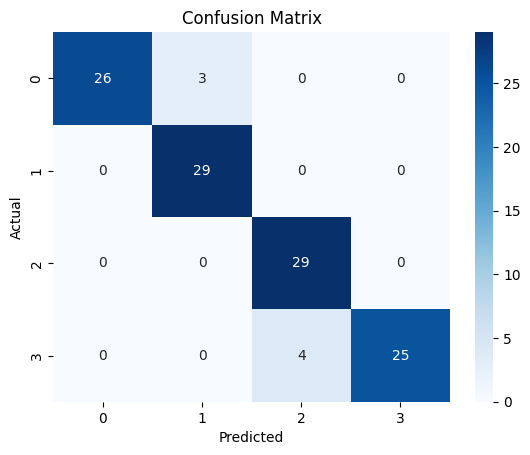

In [17]:


y_pred_real = rf_model.predict(X_real)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy
accuracy = accuracy_score(y_true, y_pred_real)
print(" Model Accuracy on Balanced Real Data:", accuracy)

# Classification report
print("\nClassification Report:\n", classification_report(y_true, y_pred_real))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_real)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


FEATURE IMPORTANCE ANALYSIS

Feature Importance Ranking:
                     Feature  Importance
       Scan Glucose (mmol/L)    0.409853
                    Vomiting    0.182769
   Historic Glucose (mmol/L)    0.167691
                      Thirst    0.072229
                      Nausea    0.062930
                     Fatigue    0.039210
                    Weakness    0.030682
                   Shakiness    0.028607
       Carbohydrates (grams)    0.002675
Rapid-Acting Insulin (units)    0.001803
 Long-Acting Insulin (units)    0.001551


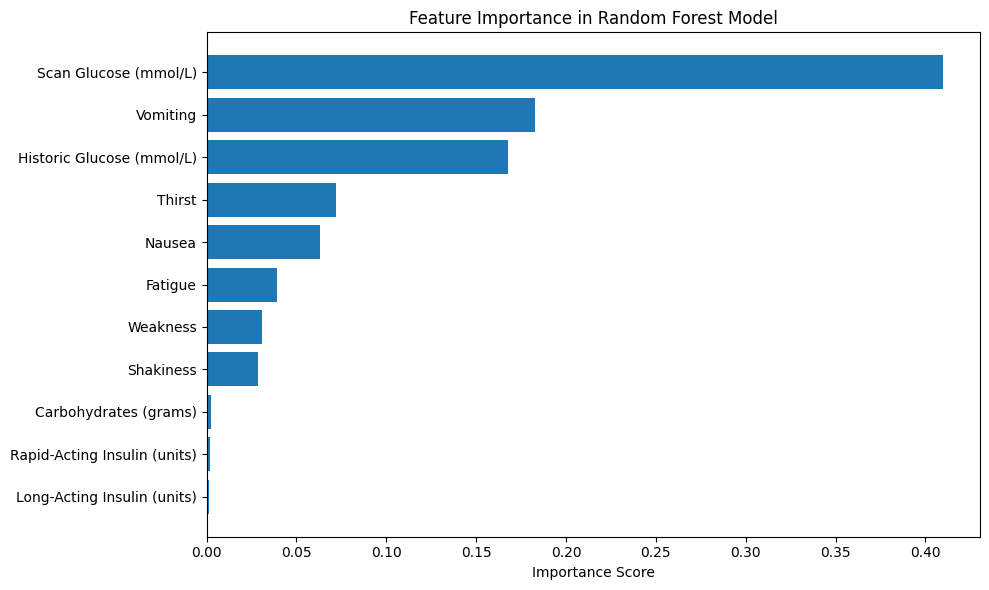

In [18]:

#  FEATURE IMPORTANCE ANALYSIS

print("FEATURE IMPORTANCE ANALYSIS")

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance Ranking:")
print(feature_importance.to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance Score')
plt.title('Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:

#  BASELINE MODEL PERFORMANCE


print(" BASELINE MODEL PERFORMANCE")


# Test set performance: how well your model learned from synthetic patterns.
y_pred_test = rf_model.predict(X_test)
baseline_test_acc = accuracy_score(y_test, y_pred_test)
print(f"\nTest Set Accuracy (All Features): {baseline_test_acc:.4f}")

# Real data performance: how well it transfers that learning to actual patient data.
y_pred_real = rf_model.predict(X_real)
baseline_real_acc = accuracy_score(y_true, y_pred_real)
print(f"Real Data Accuracy (All Features): {baseline_real_acc:.4f}")

 BASELINE MODEL PERFORMANCE

Test Set Accuracy (All Features): 1.0000
Real Data Accuracy (All Features): 0.9397


 ABLATION STUDY - REMOVING ONE FEATURE AT A TIME

 Testing WITHOUT: Historic Glucose (mmol/L)
   Test Accuracy: 1.0000 (Impact: +0.0000)
   Real Accuracy: 0.9655 (Impact: -0.0259)

 Testing WITHOUT: Scan Glucose (mmol/L)
   Test Accuracy: 0.9590 (Impact: +0.0410)
   Real Accuracy: 0.7759 (Impact: +0.1638)

 Testing WITHOUT: Rapid-Acting Insulin (units)
   Test Accuracy: 1.0000 (Impact: +0.0000)
   Real Accuracy: 0.9655 (Impact: -0.0259)

 Testing WITHOUT: Long-Acting Insulin (units)
   Test Accuracy: 1.0000 (Impact: +0.0000)
   Real Accuracy: 0.9655 (Impact: -0.0259)

 Testing WITHOUT: Carbohydrates (grams)
   Test Accuracy: 1.0000 (Impact: +0.0000)
   Real Accuracy: 0.9655 (Impact: -0.0259)

 Testing WITHOUT: Thirst
   Test Accuracy: 1.0000 (Impact: +0.0000)
   Real Accuracy: 0.9569 (Impact: -0.0172)

 Testing WITHOUT: Nausea
   Test Accuracy: 1.0000 (Impact: +0.0000)
   Real Accuracy: 0.9397 (Impact: +0.0000)

 Testing WITHOUT: Weakness
   Test Accuracy: 1.0000 (Impact: +0.0000)
   R

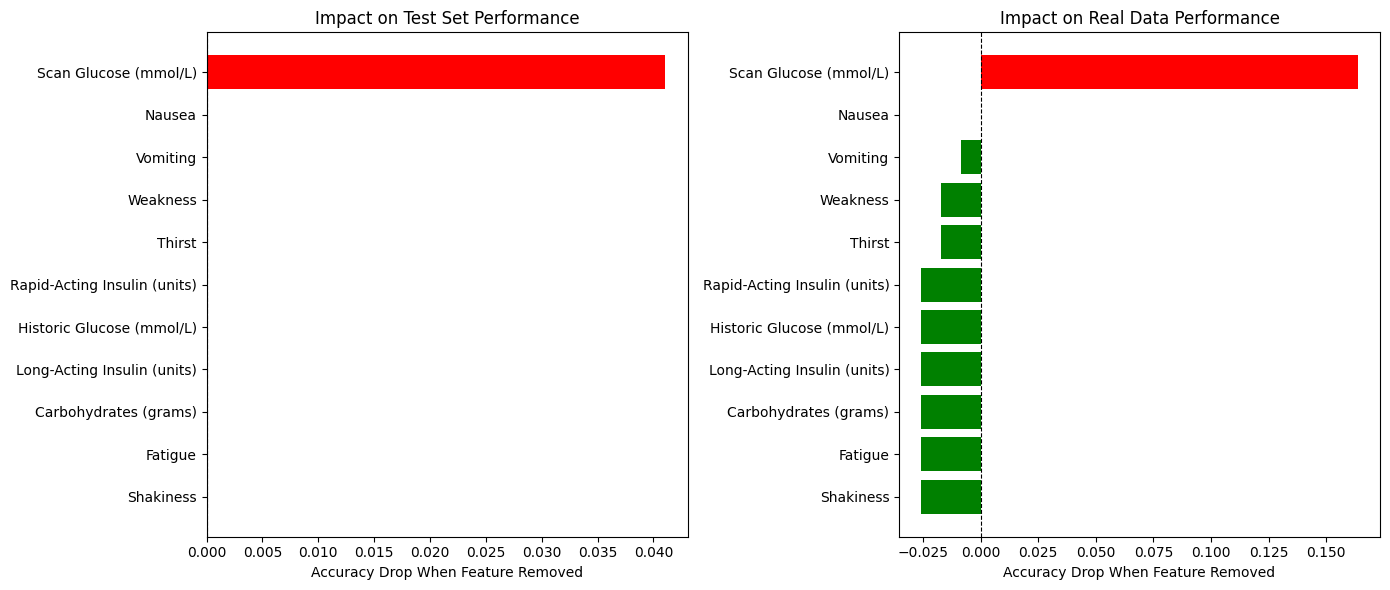

In [20]:

#  ABLATION STUDY - Remove One Feature at a Time


print(" ABLATION STUDY - REMOVING ONE FEATURE AT A TIME")


ablation_results = []

# Loop through each feature
for feature in X_train.columns:
    print(f"\n Testing WITHOUT: {feature}")
    
    # Create dataset without this feature
    X_train_ablated = X_train.drop(columns=[feature])
    X_test_ablated = X_test.drop(columns=[feature])
    X_real_ablated = X_real.drop(columns=[feature])
    
    # Train new model
    model_ablated = RandomForestClassifier(n_estimators=100, random_state=42)
    model_ablated.fit(X_train_ablated, y_train)
    
    # Test performance : synthetic test set
    y_pred_test_ablated = model_ablated.predict(X_test_ablated)
    test_acc = accuracy_score(y_test, y_pred_test_ablated)

    # Real data performance : how well it transfers that learning to actual patient data.
    y_pred_real_ablated = model_ablated.predict(X_real_ablated)
    real_acc = accuracy_score(y_true, y_pred_real_ablated)
    
    # Calculate impact
    test_impact = baseline_test_acc - test_acc
    real_impact = baseline_real_acc - real_acc
    
    ablation_results.append({
        'Removed Feature': feature,
        'Test Accuracy': test_acc,
        'Test Impact': test_impact,
        'Real Accuracy': real_acc,
        'Real Impact': real_impact
    })
    
    print(f"   Test Accuracy: {test_acc:.4f} (Impact: {test_impact:+.4f})")
    print(f"   Real Accuracy: {real_acc:.4f} (Impact: {real_impact:+.4f})")

# Convert to DataFrame
ablation_df = pd.DataFrame(ablation_results)
ablation_df = ablation_df.sort_values('Real Impact', ascending=False)

print("ABLATION STUDY SUMMARY (Sorted by Real Data Impact)")
print(ablation_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Test set impact
axes[0].barh(ablation_df['Removed Feature'], ablation_df['Test Impact'], 
             color=['red' if x > 0 else 'green' for x in ablation_df['Test Impact']])
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Accuracy Drop When Feature Removed')
axes[0].set_title('Impact on Test Set Performance')
axes[0].invert_yaxis()

# Real data impact
axes[1].barh(ablation_df['Removed Feature'], ablation_df['Real Impact'],
             color=['red' if x > 0 else 'green' for x in ablation_df['Real Impact']])
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Accuracy Drop When Feature Removed')
axes[1].set_title('Impact on Real Data Performance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [21]:

#  FEATURE GROUP ANALYSIS - how well different categories of features perform when used together


print("FEATURE GROUP ANALYSIS")


feature_groups = {
    'Glucose Only': ['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)'],
    'Insulin Only': ['Rapid-Acting Insulin (units)', 'Long-Acting Insulin (units)'],
    'Carbs Only': ['Carbohydrates (grams)'],
    'Symptoms Only': ['Thirst', 'Nausea', 'Weakness', 'Vomiting', 'Fatigue', 'Shakiness'],
    'Glucose + Insulin': ['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)', 
                          'Rapid-Acting Insulin (units)', 'Long-Acting Insulin (units)'],
    'No Symptoms': ['Historic Glucose (mmol/L)', 'Scan Glucose (mmol/L)',
                    'Rapid-Acting Insulin (units)', 'Long-Acting Insulin (units)',
                    'Carbohydrates (grams)']
}

group_results = []

#loop through each feature group
for group_name, features in feature_groups.items():
    print(f"\n Testing with: {group_name}")
    
    # Select only these features
    X_train_group = X_train[features]
    X_test_group = X_test[features]
    X_real_group = X_real[features]
    
    # Train model
    model_group = RandomForestClassifier(n_estimators=100, random_state=42)
    model_group.fit(X_train_group, y_train)
    
    # Evaluate
    test_acc = accuracy_score(y_test, model_group.predict(X_test_group))
    real_acc = accuracy_score(y_true, model_group.predict(X_real_group))
    
    group_results.append({
        'Feature Group': group_name,
        'Num Features': len(features),
        'Test Accuracy': test_acc,
        'Real Accuracy': real_acc
    })
    
    print(f"   Test Accuracy: {test_acc:.4f}")
    print(f"   Real Accuracy: {real_acc:.4f}")

# Display results
group_df = pd.DataFrame(group_results)
group_df = group_df.sort_values('Real Accuracy', ascending=False)

print("\n" + "=" * 60)
print("FEATURE GROUP COMPARISON")
print("=" * 60)
print(group_df.to_string(index=False))

FEATURE GROUP ANALYSIS

 Testing with: Glucose Only
   Test Accuracy: 1.0000
   Real Accuracy: 1.0000

 Testing with: Insulin Only
   Test Accuracy: 0.3910
   Real Accuracy: 0.2414

 Testing with: Carbs Only
   Test Accuracy: 0.4025
   Real Accuracy: 0.2500

 Testing with: Symptoms Only
   Test Accuracy: 0.9275
   Real Accuracy: 0.6897

 Testing with: Glucose + Insulin
   Test Accuracy: 1.0000
   Real Accuracy: 1.0000

 Testing with: No Symptoms
   Test Accuracy: 1.0000
   Real Accuracy: 1.0000

FEATURE GROUP COMPARISON
    Feature Group  Num Features  Test Accuracy  Real Accuracy
     Glucose Only             2         1.0000       1.000000
      No Symptoms             5         1.0000       1.000000
Glucose + Insulin             4         1.0000       1.000000
    Symptoms Only             6         0.9275       0.689655
       Carbs Only             1         0.4025       0.250000
     Insulin Only             2         0.3910       0.241379


 FEATURE CORRELATION ANALYSIS


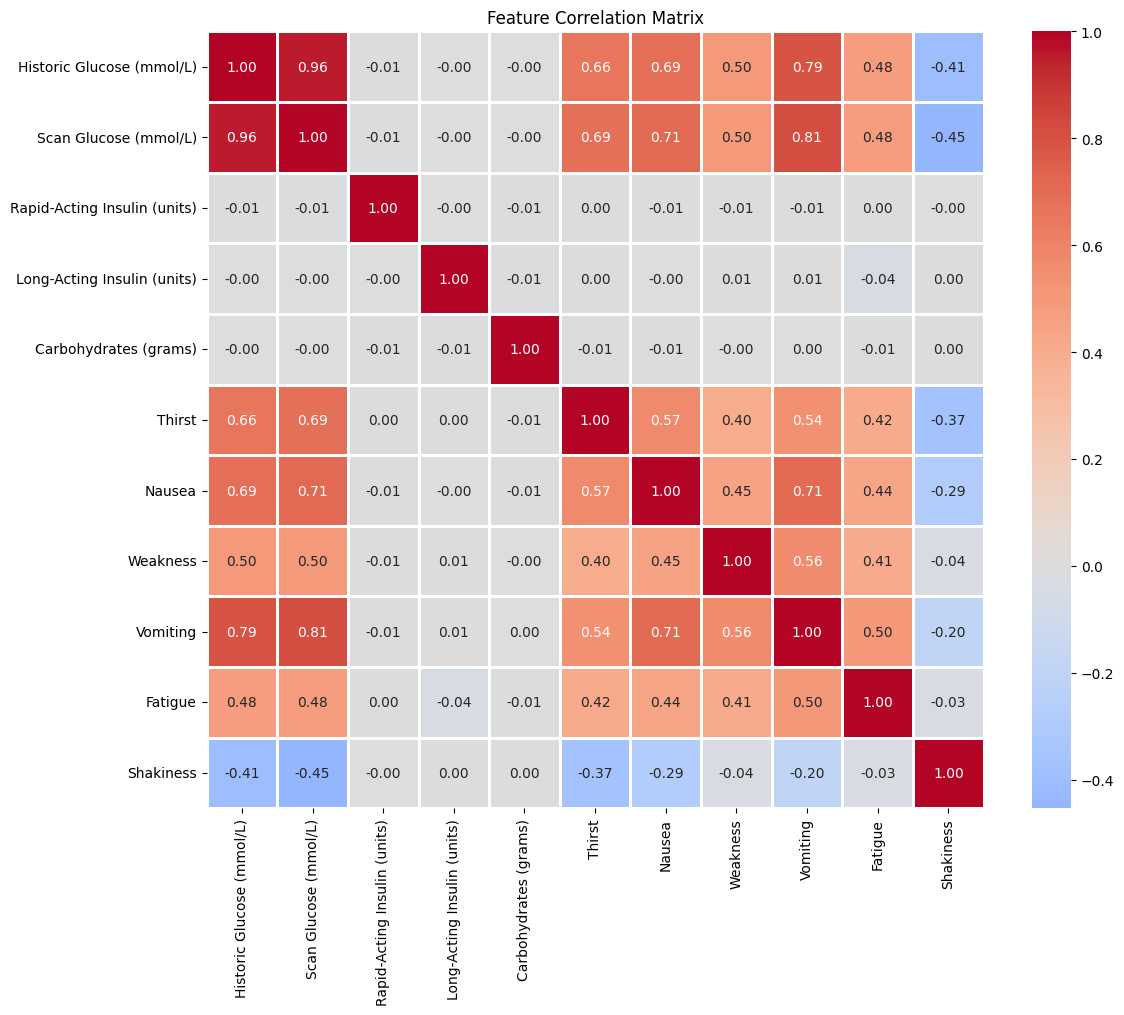

In [22]:

#  FEATURE CORRELATION ANALYSIS

print(" FEATURE CORRELATION ANALYSIS")


# Calculate correlation matrix
correlation_matrix = X_train.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [23]:
import pickle
import joblib

# Option A: Use joblib (RECOMMENDED for sklearn models)
joblib.dump(rf_model, 'diabetes_model.joblib')

# Save feature names and metadata separately
model_metadata = {
    'feature_names': X_train.columns.tolist(),
    'condition_map': {0: "Hypoglycemia", 1: "Normal", 2: "Hyperglycemia", 3: "DKA"},
    'feature_importance': dict(zip(X_train.columns, rf_model.feature_importances_)),
    'test_accuracy': accuracy_score(y_test, rf_model.predict(X_test)),
}

with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)

print(" Model saved as 'diabetes_model.joblib'")
print(" Metadata saved as 'model_metadata.pkl'")

 Model saved as 'diabetes_model.joblib'
 Metadata saved as 'model_metadata.pkl'
